# Regresion linal usando el modulo scipy

In [ ]:
! pip show scipy

Name: scipy
Version: 1.6.2
Summary: SciPy: Scientific Library for Python
Home-page: https://www.scipy.org
Author: None
Author-email: None
License: BSD
Location: /home/leon/anaconda3/lib/python3.8/site-packages
Requires: numpy
Required-by: jitcode, statsmodels, seaborn, scikit-learn, scikit-image


In [ ]:
from scipy import stats   # Carga el módulo de herramientas estadísticas

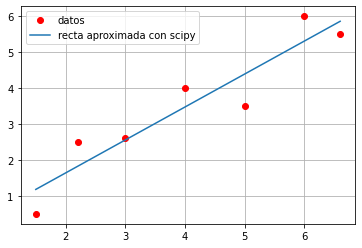

In [ ]:
#datos que queremos ajustar
x = [1.5  ,2.2  ,3 ,4 ,5  ,6,6.6]
y = [0.5,2.5,2.6 ,4 ,3.5,6,5.5]


#Haciendo la regresion lineal con scipy
regresion_lineal = stats.linregress(x,y)

# Resultados del análisis
beta0 = regresion_lineal.intercept   # Intercepto
beta1 = regresion_lineal.slope       # Pendiente


L2 =   beta1* np.array(x) + beta0


#--------------graficando---------------------------
#Graficando las parejas de datos
plt.plot(  x  , y , "or" , label="datos" )


#Graficando la recta segun m y b
plt.plot(  x , L2 , label="recta aproximada con scipy"  )


#mostrando las legendas del grafico
plt.grid()
plt.legend()

#Mostrando el gráfico
plt.show()


---
---

# Ejercicio tipo examen: Determinación de la energía de activación de una reacción


---
---



**Contexto:**

Las reacciones químicas ocurren más rápidamente a temperaturas más altas; por ejemplo, la leche se pone agria mucho más rápidamente si se almacena a temperatura ambiente en lugar de refrigerarla.  

La [velocidad de reacción](https://en.wikipedia.org/wiki/Reaction_rate) $k$ permite estimar la cantidad de sustancia que se transforma por unidad de tiempo en una reacción química determinada. La ecuación de Arrhenius suministra una relación matemática entre la velocidad de reacción $k$ y la temperatura $T$. Este modelo se basa en la idea de que a  medida que aumenta la temperatura, las moléculas se mueven más rápido y chocan con mayor intensidad, aumentando la probabilidad de que ocurra una reacción química.

De acuerdo con esta ecuación
$$k = A\cdot \exp\left( -~\frac{E}{R\cdot T}\right),$$
donde
- $k$ es la velocidad de reacción ($\text{s}^{-1}$)
- $T$ es la temperatura absoluta ($\text{K}$)
- $A$ es un factor constante (*factor de frecuencia*, $\text{s}^{-1}$)
- $E$ es la energía de activación de la reacción ($\text{J}\cdot\text{mol}^{-1}$)
- $R = 8.31~\text{J}\cdot\text{K}^{−1}\cdot\text{mol}^{−1}$ es la constante universal de los gases



**Problema:**

En un experimento se midió la velocidad de reacción en función de la temperatura para la reacción
$$\text{CO}(g)+\text{NO}_2(g) \longrightarrow \text{CO}_2(g)+\text{NO}(g),$$
y se obtuvieron los resultados mostrados en la siguiente tabla:

$$
\begin{aligned}
&\begin{array}{|c|c|}
\hline \hline T~\text{(°C)} & k~\text{(1/s)} \\ \hline
325 & 0.028 \\
378 & 0.22 \\
429 & 1.3 \\
475 & 6.0 \\
530 & 30 \\\hline
\end{array}
\end{aligned}
$$


Considerando lo anterior realice las siguientes tareas:

1. (20%) A partir de la ecuación de Arrhenius, proponga un cambio para las variables experimentales $(T, k)$ que permita obtener una relación lineal entre las variables transformadas.

2. (20%) Haga una gráfica para los datos originales y otra para los datos transformados. Tome en cuenta el utilizar las etiquetas adecuadas para los ejes coordenados, en el cual se incluyan las unidades de las cantidades relacionadas.

3. (20%) Realice una regresión lineal a los datos transformados y estime el valor de la constante ($A$) y la energía de activación ($E$) para la reacción dada. Presente los valores estimados indicando claramente las unidades correspondientes.

4. (20%) Usando el modelo obtenido, estime la velocidad de reacción para temperaturas de 300 y 400°C.


5. (20%) Realice una gráfica $k$ vs $T$(°C) que incluya los datos experimetnales y los del modelo. Guarde la gráfica como $\texttt{velocidad_reaccion.pdf}$

**Solución:**

**1. Cambio de variables**

> En este caso, el modelo a usar es justamente la ecuación de Arrhenius de tal manera que, tomando logaritmo a lado y lado de ésta, se tiene  
$$ \begin{eqnarray}
k & = & A\cdot \exp\left( -\frac{E}{R\cdot T}\right) \\
\ln(k) &=& \ln(A) -  E  \left( \frac{1}{R\cdot T}\right) \\
\color{red}{Y} &=& \ln(A) - E \cdot\color{red}{X}
\end{eqnarray} $$
>
> A partir de una regresión lineal
$$\color{red}{Y} = b + m \cdot\color{red}{X}$$
para las nuevas variables $X=1/(R\cdot T)$ y $Y=\ln(k)$ se pueden obtener tanto el intercepto $b$ como la pendiente $m$, y por lo tanto, los parámetros del modelo $A=\exp(b)$ y $E=-m$.

**2. Cambio de variables**

Datos T = [325 378 429 475 530] °C
Datos k =  [2.8e-02 2.2e-01 1.3e+00 6.0e+00 3.0e+01] 1/s


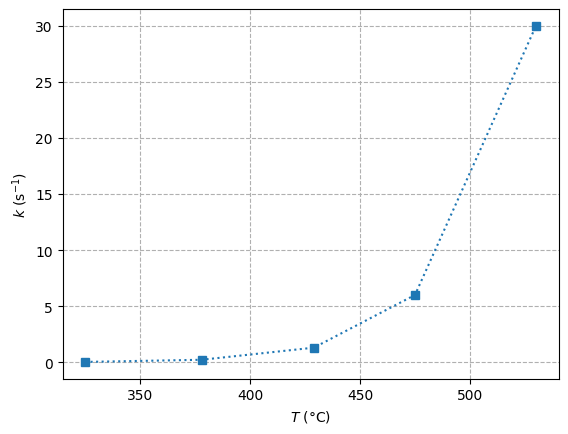

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Parámetros
R = 8.31

# Datos experimentales
T_en_C = np.array([325, 378, 429, 475, 530])
k_med  = np.array([0.028,0.22,1.3,6.0,30])

print('Datos T =', T_en_C, '°C')
print('Datos k = ',k_med, '1/s')

plt.plot(T_en_C,k_med,'s:')
plt.xlabel(r'$T$ (°C)')
plt.ylabel(r'$k$ (s$^{-1}$)')
plt.grid(linestyle='dashed')
plt.show()

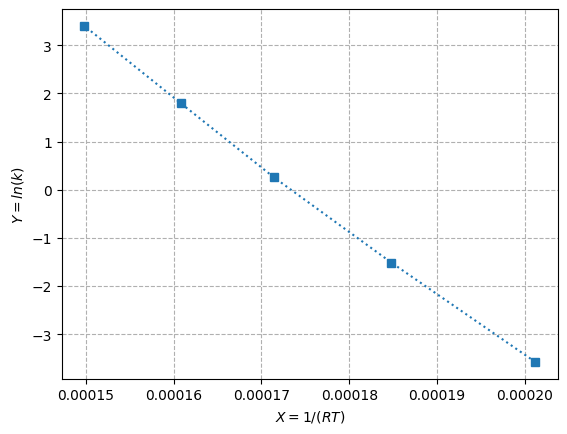

In [ ]:
# Datos transformados  (linealización)

T_en_K = T_en_C + 273.15 # Unidades correctas para ajustar a
                         # la ecuación de Arrhenius

datos_X = 1/(R*T_en_K)
datos_Y = np.log(k_med)

plt.plot(datos_X,datos_Y,'s:')
plt.xlabel('$X = 1/(RT)$')
plt.ylabel('$Y = ln(k)$')
plt.grid(linestyle='dashed')
plt.show()

**3. Regresión**

In [ ]:
import scipy.stats as stat

# Regresion lineal usando scipy
regresion_lineal = stat.linregress(datos_X, datos_Y)

# Parámetros de la regresión
intercepto = regresion_lineal.intercept
pendiente  = regresion_lineal.slope

print('Los parámetros de la regresión lineal son:')
print('   pendiente = %8.2e' % pendiente)             # El formato %8.2e permite expresar
print('  intercepto = %8.2e' % intercepto, '\n')      # los valores en notación científica

# Parámetros del modelo
A_mod  = np.exp(intercepto)
E_mod = -pendiente

print('Los parámetros del modelo obtenidos son:')
print('   Coeficiente de frecuencia A = %8.2e' % A_mod, '1/s')
print('       Energía de activación E = %8.2e' % E_mod, 'J/mol')

Los parámetros de la regresión lineal son:
   pendiente = -1.36e+05
  intercepto = 2.37e+01 

Los parámetros del modelo obtenidos son:
   Coeficiente de frecuencia A = 1.87e+10 1/s
       Energía de activación E = 1.36e+05 J/mol


**4. Predicción**

In [ ]:
T_300 = 300+273.15 # Unidades adecuadas
k_300 = A_mod * np.exp(- E_mod / (R*T_300) )
print('La velocidad de reacción para T=300°C es k = %8.2e' % k_300, '1/s\n')

T_400 = 400+273.15 # Unidades adecuadas
k_400 = A_mod * np.exp(- E_mod / (R*T_400) )
print('La velocidad de reacción para T=400°C es k = %8.2e' %  k_400, '1/s')

La velocidad de reacción para T=300°C es k = 7.72e-03 1/s

La velocidad de reacción para T=400°C es k = 5.34e-01 1/s


**5. Almacenamiento de resultados**

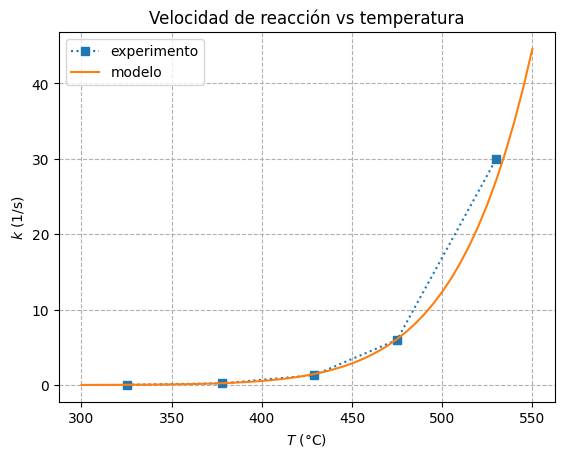

In [ ]:
#  Prepara los datos en el rango requerido
T_modelo_C = np.arange(300,551,5)  # °C

T_modelo_K = T_modelo_C  + 273.15  # K

k_modelo = A_mod * np.exp(-E_mod/(R*T_modelo_K))



# Grafica los datos originales y la predicción del modelo
plt.plot(T_en_C,k_med,'s:',label='experimento')
plt.plot(T_modelo_C,k_modelo,'-',label='modelo')
plt.xlabel('$T$ (°C)')
plt.ylabel('$k$ (1/s)')
plt.title('Velocidad de reacción vs temperatura')
plt.legend()

plt.savefig('velocidad_reaccion.pdf')
plt.show()